<a href="https://colab.research.google.com/github/manasavankayala/opencv-lab/blob/main/exp9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving fruit.jpeg to fruit.jpeg


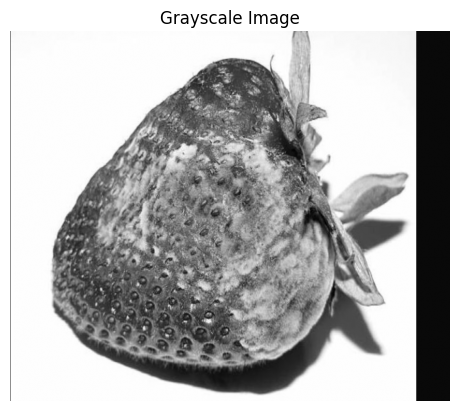

In [1]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

# Upload and read image
uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()

Saving fruit.jpeg to fruit (1).jpeg


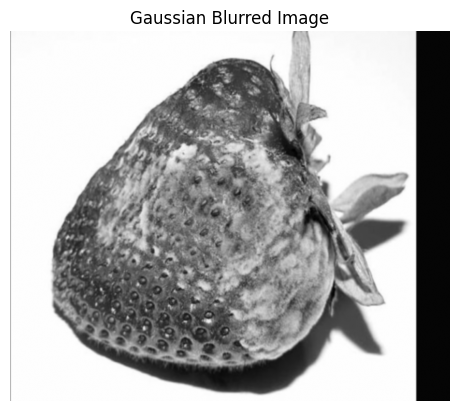

In [2]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

# Upload and read image
uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur
blur = cv2.GaussianBlur(gray, (5,5), 0)

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis('off')
plt.show()

Saving fruit.jpeg to fruit (2).jpeg


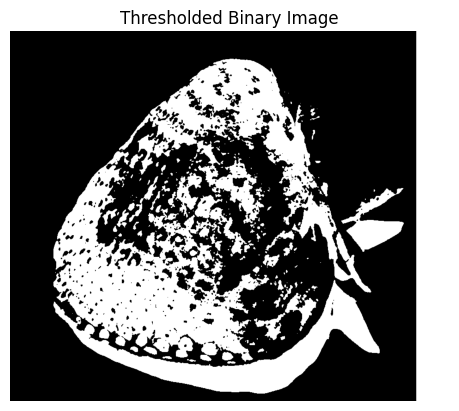

In [3]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Thresholding
ret, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Binary Image")
plt.axis('off')
plt.show()

Saving fruit.jpeg to fruit (3).jpeg


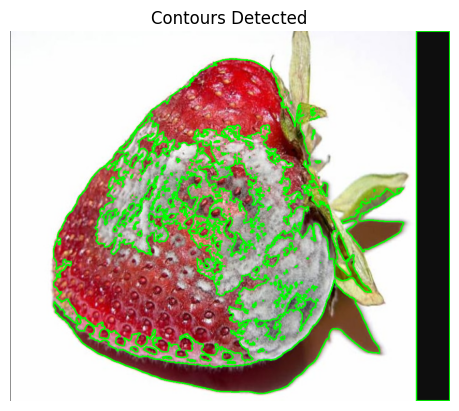

In [4]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
ret, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

# Detect contours
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Draw contours on copy of original image
output = img.copy()
cv2.drawContours(output, contours, -1, (0,255,0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Contours Detected")
plt.axis('off')
plt.show()

Saving fruit.jpeg to fruit (4).jpeg


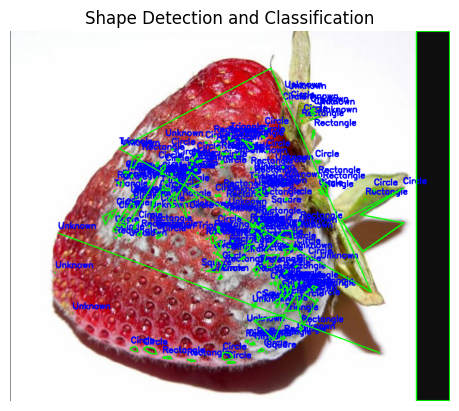

In [5]:
import cv2
from google.colab import files
import matplotlib.pyplot as plt

uploaded = files.upload()
img = cv2.imread(list(uploaded.keys())[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5,5), 0)
ret, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = img.copy()

for cnt in contours:
    epsilon = 0.04 * cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, epsilon, True)

    # Shape identification
    if len(approx) == 3:
        shape = "Triangle"
    elif len(approx) == 4:
        x, y, w, h = cv2.boundingRect(approx)
        ar = w / float(h)
        shape = "Square" if 0.95 <= ar <= 1.05 else "Rectangle"
    elif len(approx) > 4:
        shape = "Circle"
    else:
        shape = "Unknown"

    # Draw contour and label
    cv2.drawContours(output, [approx], 0, (0,255,0), 2)
    x, y = approx.ravel()[0], approx.ravel()[1]
    cv2.putText(output, shape, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Shape Detection and Classification")
plt.axis('off')
plt.show()